In [21]:
import zipfile

zip_ref = zipfile.ZipFile("garbage-classification.zip", 'r')
zip_ref.extractall("dataset")
zip_ref.close()

In [22]:
import os
import shutil
import random

In [23]:
os.listdir("dataset")

['garbage_classification']

In [25]:
os.listdir("dataset/garbage_classification")

['clothes',
 'white-glass',
 'biological',
 'battery',
 'cardboard',
 'metal',
 'brown-glass',
 'green-glass',
 'shoes',
 'trash',
 'plastic',
 'paper']

In [28]:
import os

base_dir = "dataset"
train_dir = os.path.join(base_dir,"train")
val_dir = os.path.join(base_dir,"validation")

classes = ["cardboard","metal","paper","plastic","trash"]

for cls in classes:
    os.makedirs(os.path.join(train_dir,cls),exist_ok=True)
    os.makedirs(os.path.join(val_dir,cls),exist_ok=True)

In [29]:
source_dir = "dataset/garbage_classification"

for cls in classes:

    class_path = os.path.join(source_dir,cls)
    images = os.listdir(class_path)

    random.shuffle(images)

    split = int(0.8*len(images))

    train_images = images[:split]
    val_images = images[split:]

    for img in train_images:
        shutil.copy(os.path.join(class_path,img),
                    os.path.join(train_dir,cls,img))

    for img in val_images:
        shutil.copy(os.path.join(class_path,img),
                    os.path.join(val_dir,cls,img))

In [30]:
os.listdir("dataset/train")

['cardboard', 'metal', 'trash', 'plastic', 'paper']

In [31]:
os.listdir("dataset/train/paper")[:5]

['paper458.jpg',
 'paper438.jpg',
 'paper782.jpg',
 'paper748.jpg',
 'paper131.jpg']

In [32]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

2026-03-15 13:00:52.272475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 13:00:53.994908: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 13:01:01.941922: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [33]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [34]:
train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "dataset/validation",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 4120 images belonging to 5 classes.
Found 1560 images belonging to 5 classes.


In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [36]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1773580080.808801     631 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [37]:
for layer in base_model.layers:
    layer.trainable = False

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D

In [40]:
model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(5, activation='softmax'))

In [41]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [42]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


2026-03-15 13:28:21.849458: I external/local_xla/xla/service/service.cc:163] XLA service 0x725b24010b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-15 13:28:21.849567: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-15 13:28:22.247155: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-15 13:28:25.433730: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2026-03-15 13:28:25.765025: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 13:28:25.

 27/129 ━━━━━━━━━━━━━━━━━━━━ 1:01 602ms/step - accuracy: 0.5392 - loss: 1.1491

2026-03-15 13:29:30.503412: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 13:29:33.525621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4156', 268 bytes spill stores, 268 bytes spill loads

2026-03-15 13:29:49.378686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 13:29:49.644559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please

129/129 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8323 - loss: 0.4631 - val_accuracy: 0.9212 - val_loss: 0.2343
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 86s 660ms/step - accuracy: 0.9245 - loss: 0.2289 - val_accuracy: 0.9282 - val_loss: 0.1765
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 90s 698ms/step - accuracy: 0.9383 - loss: 0.1854 - val_accuracy: 0.9615 - val_loss: 0.1284
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 84s 648ms/step - accuracy: 0.9451 - loss: 0.1475 - val_accuracy: 0.9628 - val_loss: 0.1054
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 81s 631ms/step - accuracy: 0.9563 - loss: 0.1255 - val_accuracy: 0.9660 - val_loss: 0.0965
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 86s 664ms/step - accuracy: 0.9617 - loss: 0.1049 - val_accuracy: 0.9712 - val_loss: 0.0876
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 67s 520ms/step - accuracy: 0.9629 - loss: 0.1000 - val_accuracy: 0.9628 - val_loss: 0.1122
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 65s 502ms/step - accuracy: 0.9704 - loss: 0.0784 - val_a

In [43]:
model.save("waste_classifier_model.h5")

In [44]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.9815533757209778
0.9846153855323792


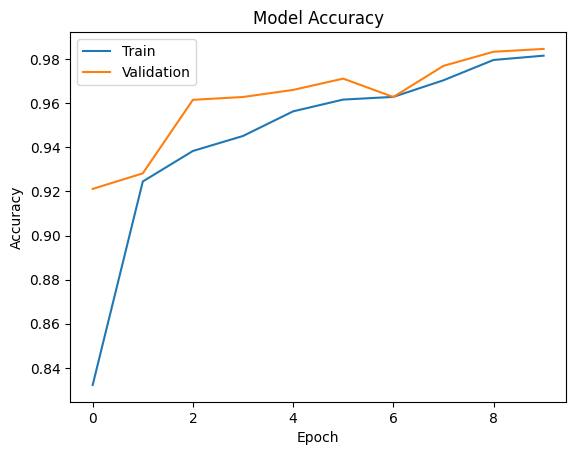

In [45]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

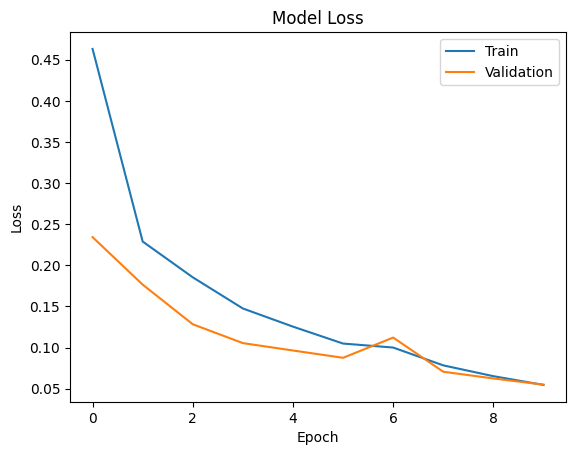

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

Actual class: trash


2026-03-15 14:43:05.782620: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv (f32[1,576,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,576,14,14]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-15 14:43:06.798696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 14:43:06.998789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optim

1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
Predicted class: trash


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

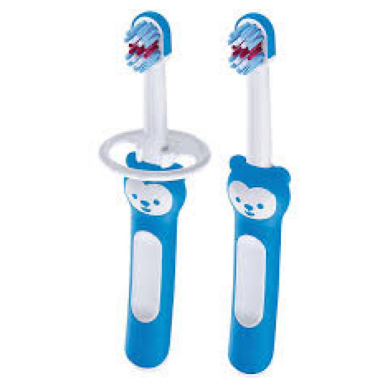

In [49]:
from tensorflow.keras.preprocessing import image
import numpy as np

# choose a random class
class_name = random.choice(os.listdir("dataset/validation"))

# choose random image from that class
img_path = os.path.join("dataset/validation", class_name, random.choice(os.listdir("dataset/validation/"+class_name)))

print("Actual class:", class_name)

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_labels = {v:k for k,v in train_generator.class_indices.items()}
predicted_class = class_labels[np.argmax(prediction)]

print("Predicted class:", predicted_class)

plt.imshow(img)
plt.axis("off")

In [50]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9846 - loss: 0.0550
Validation Loss: 0.054962433874607086
Validation Accuracy: 0.9846153855323792


49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 335ms/step


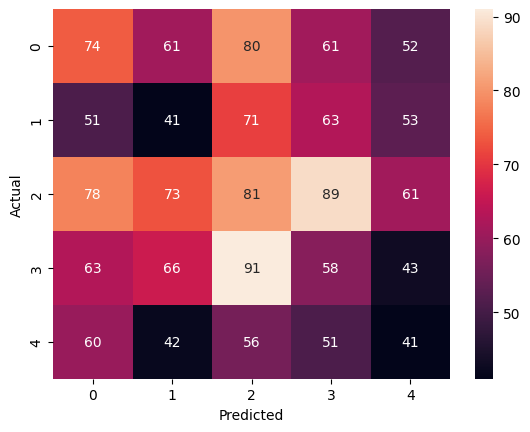

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()